# Opening Effectiveness Analysis

This notebook analyzes chess opening performance metrics using a dataset of 20,058 games from Lichess.org.

**Objectives**
- Analyze win rates by opening
- Compare opening popularity vs effectiveness
- Identify top performing openings for White and Black
- Examine opening families (ECO codes) performance patterns

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 1. Data Preparation
Loading the chess games dataset from Lichess.org containing over 20,000 games.

In [11]:
df = pd.read_csv('../data/games.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## 2. Feature Selection
Selecting relevant columns for opening effectiveness analysis and creating a focused dataset.

In [12]:
# Keep only the relevant columns
columns_to_keep = [
    'opening_name',
    'opening_eco',
    'winner',
    'white_rating',
    'black_rating',
    'turns',
    'victory_status'
]

opening_df = df[columns_to_keep].copy()

# Calculate rating difference
opening_df['rating_diff'] = opening_df['white_rating'] - opening_df['black_rating']
opening_df['abs_rating_diff'] = abs(opening_df['rating_diff'])

# Extract ECO family (first letter of ECO code)
opening_df['eco_family'] = opening_df['opening_eco'].str[0]

opening_df.info()
opening_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   opening_name     20058 non-null  str  
 1   opening_eco      20058 non-null  str  
 2   winner           20058 non-null  str  
 3   white_rating     20058 non-null  int64
 4   black_rating     20058 non-null  int64
 5   turns            20058 non-null  int64
 6   victory_status   20058 non-null  str  
 7   rating_diff      20058 non-null  int64
 8   abs_rating_diff  20058 non-null  int64
 9   eco_family       20058 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.5 MB


,opening_name,opening_eco,winner,white_rating,black_rating,turns,victory_status,rating_diff,abs_rating_diff,eco_family
0,Slav Defense: Exchange Variation,D10,white,1500,1191,13,outoftime,309,309,D
1,Nimzowitsch Defense: Kennedy Variation,B00,black,1322,1261,16,resign,61,61,B
2,King's Pawn Game: Leonardis Variation,C20,white,1496,1500,61,mate,-4,4,C
3,Queen's Pawn Game: Zukertort Variation,D02,white,1439,1454,61,mate,-15,15,D
4,Philidor Defense,C41,white,1523,1469,95,mate,54,54,C


## 3. Opening Popularity Analysis
Identifying the most and least popular openings in the dataset.

OPENING POPULARITY ANALYSIS

Total unique openings: 1477
Total games: 20,058

TOP 20 MOST POPULAR OPENINGS
                                               Games  Percentage
opening_name                                                    
Van't Kruijs Opening                             368    1.834679
Sicilian Defense                                 358    1.784824
Sicilian Defense: Bowdler Attack                 296    1.475720
French Defense: Knight Variation                 271    1.351082
Scotch Game                                      271    1.351082
Scandinavian Defense: Mieses-Kotroc Variation    259    1.291255
Queen's Pawn Game: Mason Attack                  232    1.156646
Queen's Pawn Game: Chigorin Variation            229    1.141689
Scandinavian Defense                             223    1.111776
Horwitz Defense                                  209    1.041978
Caro-Kann Defense                                199    0.992123
Philidor Defense #3                             

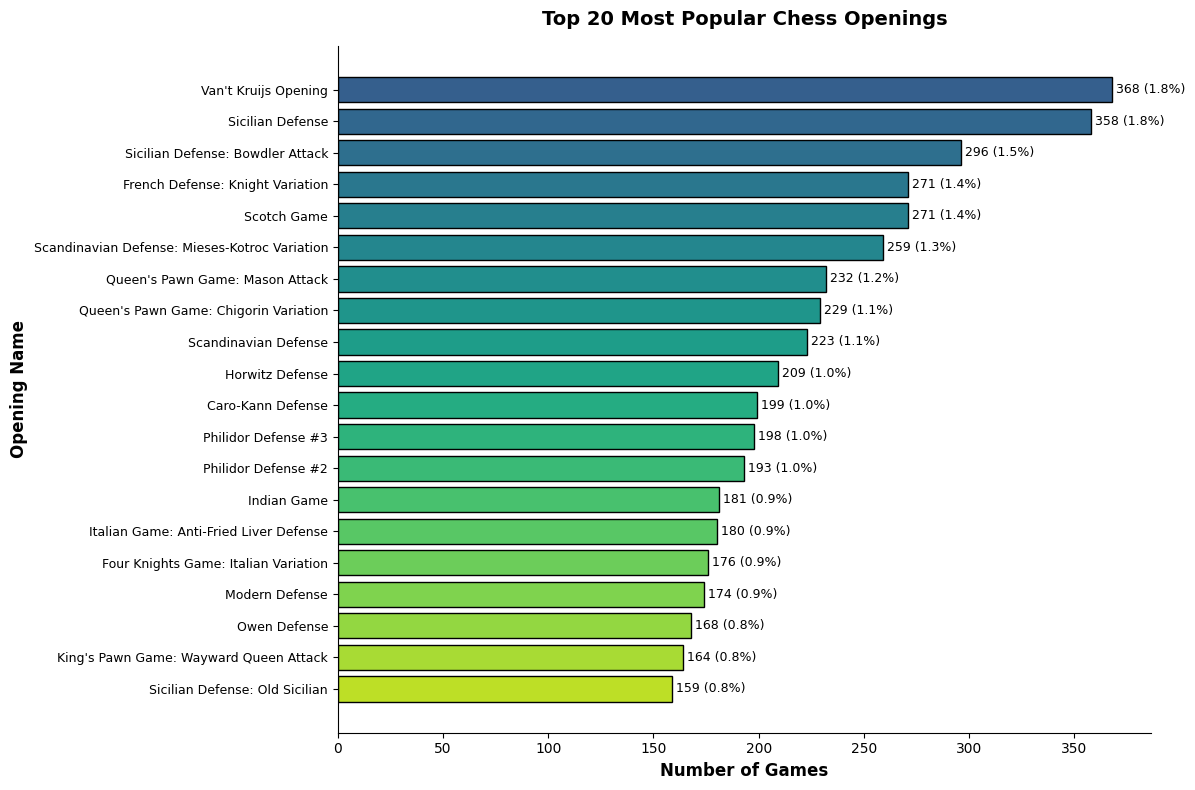

In [13]:
# Calculate opening popularity
opening_popularity = opening_df['opening_name'].value_counts()
opening_popularity_pct = opening_df['opening_name'].value_counts(normalize=True) * 100

print("="*70)
print("OPENING POPULARITY ANALYSIS")
print("="*70)
print(f"\nTotal unique openings: {len(opening_popularity)}")
print(f"Total games: {len(opening_df):,}")

print(f"\n{'='*70}")
print("TOP 20 MOST POPULAR OPENINGS")
print("="*70)
top_20 = pd.DataFrame({
    'Games': opening_popularity.head(20),
    'Percentage': opening_popularity_pct.head(20)
})
print(top_20)

# Visualize top 20 most popular openings
fig, ax = plt.subplots(figsize=(12, 8))

top_20_data = opening_popularity.head(20)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, 20))

bars = ax.barh(range(len(top_20_data)), top_20_data.values, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_20_data)))
ax.set_yticklabels(top_20_data.index, fontsize=9)
ax.invert_yaxis()

# Add value labels
for i, (idx, value) in enumerate(top_20_data.items()):
    pct = opening_popularity_pct[idx]
    ax.text(value, i, f' {value} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Number of Games', fontsize=12, fontweight='bold')
ax.set_ylabel('Opening Name', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Popular Chess Openings', fontsize=14, fontweight='bold', pad=15)
sns.despine()

plt.tight_layout()
plt.savefig('../images/03_opening_effectiveness/opening_popularity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Top Performing Openings
Identifying the best openings for White, Black, and most drawish openings.

TOP 10 OPENINGS FOR WHITE (≥50 games)
                                                     opening_name eco_code  total_games  white_win_rate  black_win_rate  draw_rate
                     Zukertort Opening: Queen's Gambit Invitation      A04           53       69.811321       24.528302   5.660377
                                            King's Knight Opening      C40           87       68.965517       29.885057   1.149425
                              King's Pawn Game: Busch-Gass Gambit      C40           58       67.241379       27.586207   5.172414
                         Queen's Gambit Refused: Marshall Defense      D06          127       66.141732       32.283465   1.574803
                                                  Elephant Gambit      C40           56       66.071429       32.142857   1.785714
                                                     Queen's Pawn      A41          129       65.891473       30.232558   3.875969
Nimzowitsch Defense: Kennedy Variation |  Lin

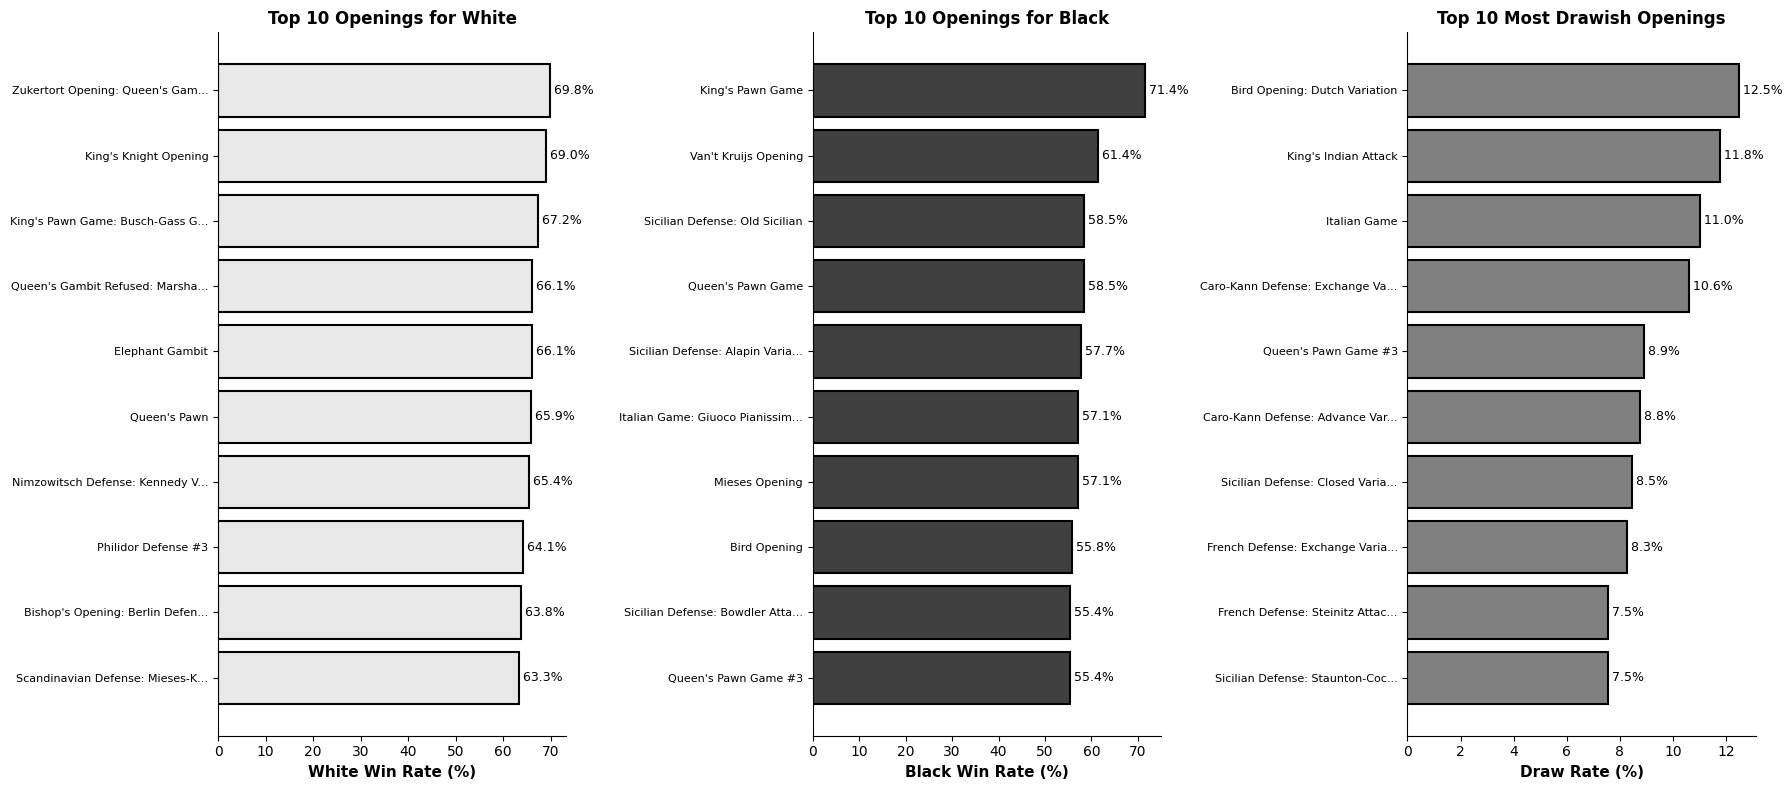

In [15]:
# Filter openings with at least 50 games for more reliable statistics
reliable_openings = opening_stats[opening_stats['total_games'] >= 50].copy()

# Top openings for White
top_white = reliable_openings.nlargest(10, 'white_win_rate')[['opening_name', 'eco_code', 'total_games', 'white_win_rate', 'black_win_rate', 'draw_rate']]

# Top openings for Black
top_black = reliable_openings.nlargest(10, 'black_win_rate')[['opening_name', 'eco_code', 'total_games', 'white_win_rate', 'black_win_rate', 'draw_rate']]

# Most drawish openings
most_drawish = reliable_openings.nlargest(10, 'draw_rate')[['opening_name', 'eco_code', 'total_games', 'white_win_rate', 'black_win_rate', 'draw_rate']]

print("="*70)
print("TOP 10 OPENINGS FOR WHITE (≥50 games)")
print("="*70)
print(top_white.to_string(index=False))

print(f"\n{'='*70}")
print("TOP 10 OPENINGS FOR BLACK (≥50 games)")
print("="*70)
print(top_black.to_string(index=False))

print(f"\n{'='*70}")
print("TOP 10 MOST DRAWISH OPENINGS (≥50 games)")
print("="*70)
print(most_drawish.to_string(index=False))

# Visualize top performing openings
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Panel 1: Top openings for White
ax1 = axes[0]
top_white_plot = top_white.head(10).sort_values('white_win_rate')
bars1 = ax1.barh(range(len(top_white_plot)), top_white_plot['white_win_rate'], 
                 color='#E8E8E8', edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(top_white_plot)))
ax1.set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_white_plot['opening_name']], fontsize=8)
ax1.set_xlabel('White Win Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Openings for White', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(top_white_plot.iterrows()):
    ax1.text(row['white_win_rate'], i, f" {row['white_win_rate']:.1f}%", va='center', fontsize=9)
sns.despine(ax=ax1)

# Panel 2: Top openings for Black
ax2 = axes[1]
top_black_plot = top_black.head(10).sort_values('black_win_rate')
bars2 = ax2.barh(range(len(top_black_plot)), top_black_plot['black_win_rate'], 
                 color='#404040', edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(top_black_plot)))
ax2.set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_black_plot['opening_name']], fontsize=8)
ax2.set_xlabel('Black Win Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 Openings for Black', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(top_black_plot.iterrows()):
    ax2.text(row['black_win_rate'], i, f" {row['black_win_rate']:.1f}%", va='center', fontsize=9)
sns.despine(ax=ax2)

# Panel 3: Most drawish openings
ax3 = axes[2]
most_drawish_plot = most_drawish.head(10).sort_values('draw_rate')
bars3 = ax3.barh(range(len(most_drawish_plot)), most_drawish_plot['draw_rate'], 
                 color='#808080', edgecolor='black', linewidth=1.5)
ax3.set_yticks(range(len(most_drawish_plot)))
ax3.set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in most_drawish_plot['opening_name']], fontsize=8)
ax3.set_xlabel('Draw Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 Most Drawish Openings', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(most_drawish_plot.iterrows()):
    ax3.text(row['draw_rate'], i, f" {row['draw_rate']:.1f}%", va='center', fontsize=9)
sns.despine(ax=ax3)

plt.tight_layout()
plt.savefig('../images/03_opening_effectiveness/top_openings.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Popularity vs Performance Analysis
Identifying overperforming and underperforming openings relative to their popularity.

POPULARITY VS PERFORMANCE ANALYSIS

Median games per opening: 50
Median White advantage: 3.96 percentage points

CATEGORY DISTRIBUTION
category
Popular & Strong    41
Average             41
Popularity Trap     40
Hidden Gem          40
Name: count, dtype: int64

TOP 10 HIDDEN GEMS (High Win Rate, Lower Popularity)
                               opening_name eco_code  total_games  white_win_rate  black_win_rate  white_advantage
            Russian Game: Damiano Variation      C42           40       80.000000       20.000000        60.000000
                            Pirc Defense #5      B07           43       74.418605       23.255814        51.162791
         English Opening: Agincourt Defense      A13           31       67.741935       25.806452        41.935484
Ruy Lopez: Morphy Defense |  Caro Variation      C70           40       67.500000       27.500000        40.000000
                        Nimzowitsch Defense      B00           36       69.444444       30.555556        38.8

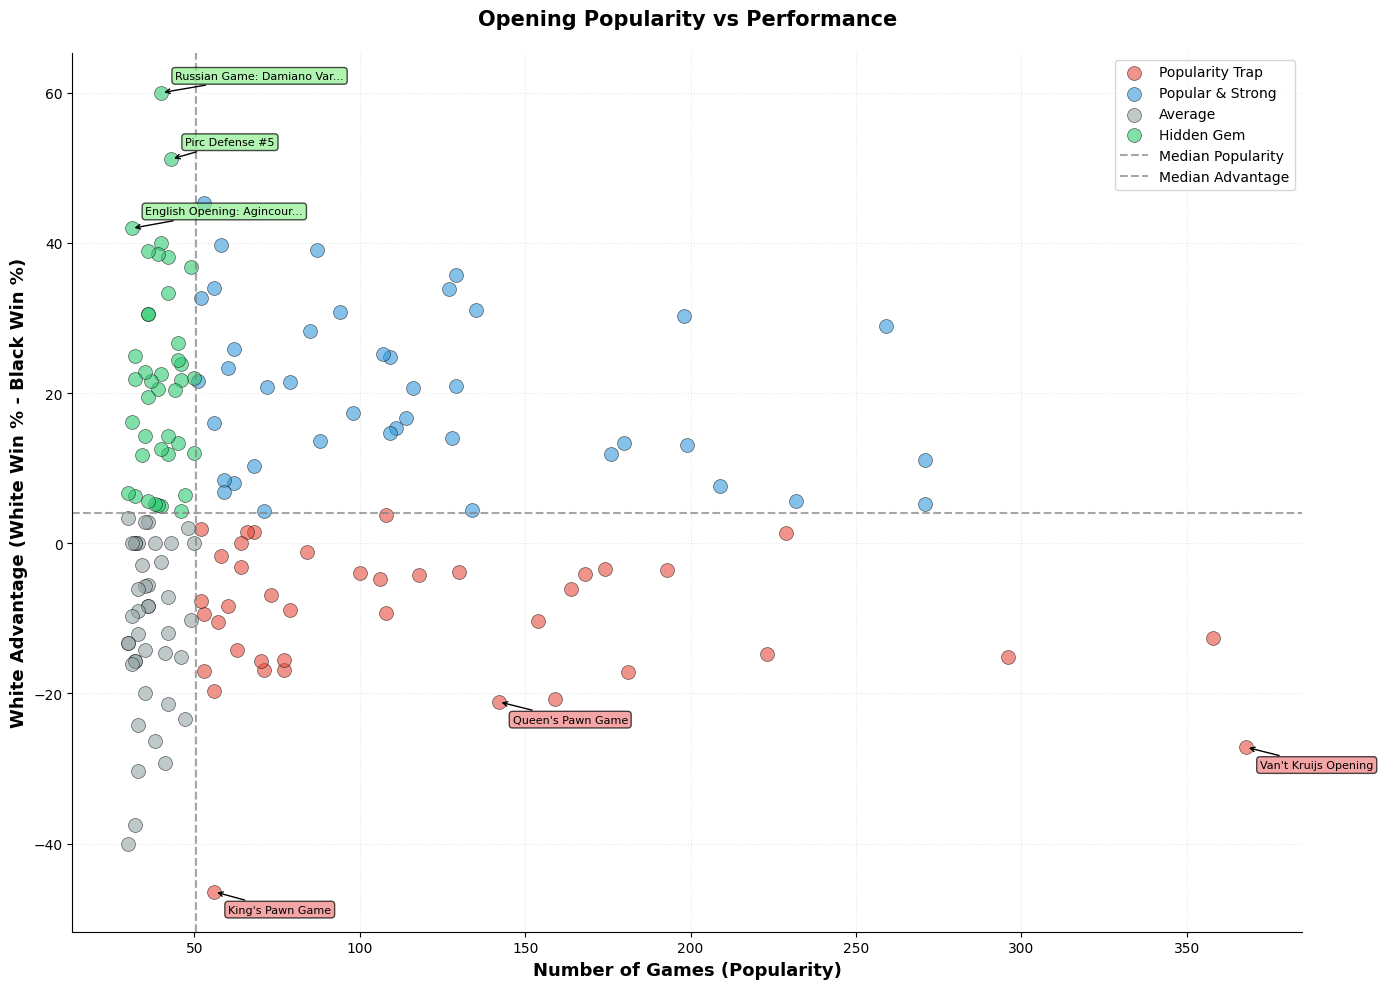

In [16]:
# Calculate White's advantage (white_win_rate - black_win_rate)
opening_stats['white_advantage'] = opening_stats['white_win_rate'] - opening_stats['black_win_rate']

# Identify hidden gems (high white advantage, lower popularity)
# and popularity traps (low white advantage, high popularity)
median_games = opening_stats['total_games'].median()
median_advantage = opening_stats['white_advantage'].median()

opening_stats['category'] = 'Average'
opening_stats.loc[
    (opening_stats['total_games'] < median_games) & (opening_stats['white_advantage'] > median_advantage),
    'category'
] = 'Hidden Gem'
opening_stats.loc[
    (opening_stats['total_games'] >= median_games) & (opening_stats['white_advantage'] < median_advantage),
    'category'
] = 'Popularity Trap'
opening_stats.loc[
    (opening_stats['total_games'] >= median_games) & (opening_stats['white_advantage'] >= median_advantage),
    'category'
] = 'Popular & Strong'

print("="*70)
print("POPULARITY VS PERFORMANCE ANALYSIS")
print("="*70)
print(f"\nMedian games per opening: {median_games:.0f}")
print(f"Median White advantage: {median_advantage:.2f} percentage points")

print(f"\n{'='*70}")
print("CATEGORY DISTRIBUTION")
print("="*70)
category_counts = opening_stats['category'].value_counts()
print(category_counts)

# Hidden gems - high performance, low popularity
hidden_gems = opening_stats[opening_stats['category'] == 'Hidden Gem'].nlargest(10, 'white_advantage')
print(f"\n{'='*70}")
print("TOP 10 HIDDEN GEMS (High Win Rate, Lower Popularity)")
print("="*70)
print(hidden_gems[['opening_name', 'eco_code', 'total_games', 'white_win_rate', 'black_win_rate', 'white_advantage']].to_string(index=False))

# Popularity traps - high popularity, lower performance
popularity_traps = opening_stats[opening_stats['category'] == 'Popularity Trap'].nsmallest(10, 'white_advantage')
print(f"\n{'='*70}")
print("TOP 10 POPULARITY TRAPS (High Popularity, Lower Win Rate)")
print("="*70)
print(popularity_traps[['opening_name', 'eco_code', 'total_games', 'white_win_rate', 'black_win_rate', 'white_advantage']].to_string(index=False))

# Visualize popularity vs performance
fig, ax = plt.subplots(figsize=(14, 10))

# Color map for categories
color_map = {
    'Hidden Gem': '#2ecc71',
    'Popularity Trap': '#e74c3c',
    'Popular & Strong': '#3498db',
    'Average': '#95a5a6'
}

for category in opening_stats['category'].unique():
    data = opening_stats[opening_stats['category'] == category]
    ax.scatter(data['total_games'], data['white_advantage'], 
              c=color_map[category], label=category, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

# Add median lines
ax.axvline(median_games, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Median Popularity')
ax.axhline(median_advantage, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Median Advantage')

# Annotate some interesting points
# Top 3 hidden gems
for idx, row in hidden_gems.head(3).iterrows():
    name = row['opening_name'][:25] + '...' if len(row['opening_name']) > 25 else row['opening_name']
    ax.annotate(name, 
               xy=(row['total_games'], row['white_advantage']),
               xytext=(10, 10), textcoords='offset points',
               fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

# Top 3 popularity traps
for idx, row in popularity_traps.head(3).iterrows():
    name = row['opening_name'][:25] + '...' if len(row['opening_name']) > 25 else row['opening_name']
    ax.annotate(name, 
               xy=(row['total_games'], row['white_advantage']),
               xytext=(10, -15), textcoords='offset points',
               fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

ax.set_xlabel('Number of Games (Popularity)', fontsize=13, fontweight='bold')
ax.set_ylabel('White Advantage (White Win % - Black Win %)', fontsize=13, fontweight='bold')
ax.set_title('Opening Popularity vs Performance', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':')
sns.despine()

plt.tight_layout()
plt.savefig('../images/03_opening_effectiveness/popularity_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()